# Choosing Visual Forms: solution

**36104 Data Visualisation and Narratives · Choosing Visual Forms**

This executable solution completes every reconstruction, intervention and
Part 2 exercise.

This is the single notebook for the class. Part 1 reconstructs nine canonical examples, one per Visual Vocabulary task family. Part 2 applies the same
reasoning to data types, tidy data and chart selection.

The reconstructions use different kinds of source material:

| Chart | Notebook input | Status |
|---|---|---|
| Yield-curve spread | FRED daily T10Y2Y snapshot | measured observations |
| HR diagram | ESA Hipparcos extract, 20,553 stars | measured observations |
| Mohs hardness scale | published ranks; Tabor's (1954) measured Vickers values | measured observations |
| Age–sex deaths | NCHS US all-cause deaths by age and sex, 2020–2023 | measured observations |
| Keeling curve | NOAA/Scripps monthly CO₂ | measured observations |
| Trophic energy pyramid | representative decade units (after Lindeman) | teaching values, clearly labelled |
| Document-topic mixtures | illustrative topic proportions | exact 100% compositions |
| Choropleth (Dupin's logic) | ABS state populations and growth, Dec 2025 | measured; abstract tile geometry |
| Minard map | standard digitisation of Minard's printed values | digitised historical data |

For each chart, run the reconstruction, verify it, then change one design
decision. Label simulated and representative values accurately.

In [1]:
# Setup: run this cell without editing it.
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd


def find_notebook_dir():
    # Find this notebook's folder from common launch locations.
    candidates = [
        Path.cwd(),
        Path.cwd() / "merged_course/classes/02-visual-forms/notebooks",
        Path.cwd().parent / "notebooks",
    ]
    for candidate in candidates:
        if (candidate / "data").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Cannot find the data folder. Launch the notebook from the course repository "
        "or keep the data folder beside the notebook."
    )


NOTEBOOK_DIR = find_notebook_dir()
DATA = NOTEBOOK_DIR / "data"
ORIGINALS = (NOTEBOOK_DIR / "../../../shared/assets/originals").resolve()

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 11,
})

print("Notebook folder:", NOTEBOOK_DIR)
print("Data files:", sorted(path.name for path in DATA.glob("*.csv")))

Notebook folder: /Users/mac/visualisation-and-intelligence-course/merged_course/classes/02-visual-forms/notebooks
Data files: ['co2_mm_mlo.csv', 'hipparcos.csv', 'minard_temp.csv', 'minard_troops.csv', 'nchs_deaths_by_age_sex.csv', 't10y2y.csv']


## 1 · The yield-curve inversion: deviation

![FRED: 10-year minus 2-year Treasury spread](../../../shared/assets/originals/fred-t10y2y.png)

The 10-year minus 2-year Treasury spread is a signed difference read against a
meaningful zero: positive is the normal upward slope, negative is an
inversion — the classic recession signal. The visual task is deviation:
variation above and below a fixed reference. `data/t10y2y.csv` is a FRED
snapshot (12 August 2026); the values are real observations.

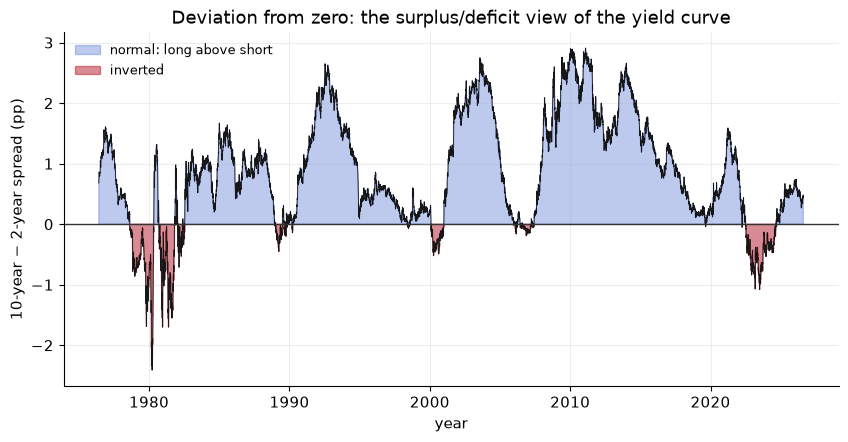

In [2]:
spread = pd.read_csv(DATA / "t10y2y.csv", parse_dates=["observation_date"])
spread = spread.rename(columns={"observation_date": "date", "T10Y2Y": "spread_pct"}).dropna()

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(spread["date"], spread["spread_pct"], color="#171717", lw=0.6)
ax.fill_between(spread["date"], spread["spread_pct"], 0,
                where=spread["spread_pct"] >= 0, color="#4269d0", alpha=0.35,
                label="normal: long above short")
ax.fill_between(spread["date"], spread["spread_pct"], 0,
                where=spread["spread_pct"] < 0, color="#b2182b", alpha=0.5,
                label="inverted")
ax.axhline(0, color="#333333", lw=1)
ax.set_xlabel("year")
ax.set_ylabel("10-year − 2-year spread (pp)")
ax.set_title("Deviation from zero: the surplus/deficit view of the yield curve")
ax.legend(frameon=False, fontsize=9)
plt.show()

In [3]:
assert spread["date"].is_monotonic_increasing
assert spread["spread_pct"].min() < 0 < spread["spread_pct"].max()
assert (spread.loc[spread["date"].dt.year == 2023, "spread_pct"] < 0).mean() > 0.9
print(f"✓ {len(spread):,} daily observations; the spread crosses its zero reference in both directions")

✓ 12,546 daily observations; the spread crosses its zero reference in both directions


**Example solution:** Without the drawn zero and the signed fills the chart
degrades to plain change over time: the reader must consult axis labels to
decide the sign, so "is the curve inverted?" stops being a glance question.
Deviation exists only against a drawn reference, and the two fill hues carry
the sign redundantly. Monthly means keep every sustained inversion episode
while erasing brief single-day crossings — acceptable for the recession-signal
reading, misleading if the claim concerns exact crossing dates.

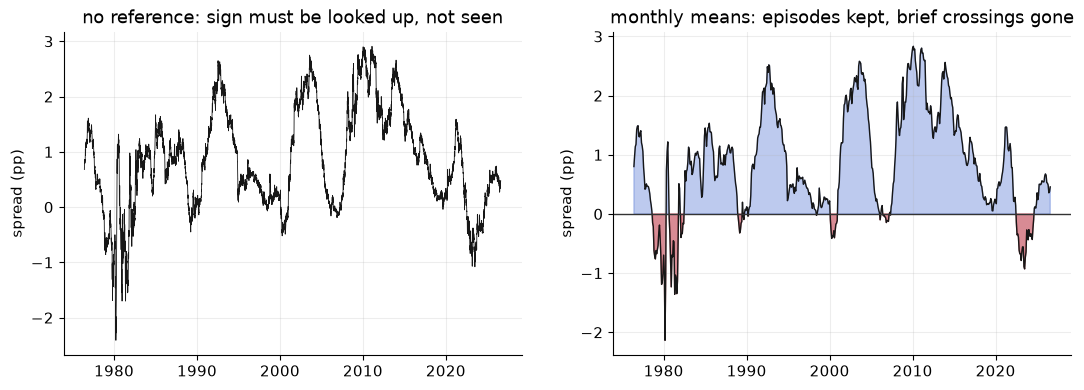

In [4]:
# Example intervention: reference removed, then monthly smoothing.
monthly = spread.set_index("date")["spread_pct"].resample("MS").mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(spread["date"], spread["spread_pct"], color="#171717", lw=0.6)
axes[0].set_title("no reference: sign must be looked up, not seen")
axes[1].plot(monthly["date"], monthly["spread_pct"], color="#171717", lw=1)
axes[1].fill_between(monthly["date"], monthly["spread_pct"], 0,
                     where=monthly["spread_pct"] >= 0, color="#4269d0", alpha=0.35)
axes[1].fill_between(monthly["date"], monthly["spread_pct"], 0,
                     where=monthly["spread_pct"] < 0, color="#b2182b", alpha=0.5)
axes[1].axhline(0, color="#333333", lw=1)
axes[1].set_title("monthly means: episodes kept, brief crossings gone")
for ax in axes:
    ax.set_ylabel("spread (pp)")
plt.show()

## 2 · The Hertzsprung–Russell diagram: correlation

*Atlas #14 — Hertzsprung–Russell diagram.*

![Russell's 1914 Figure 1](../../../shared/assets/originals/russell-1914.png)

Russell plotted absolute magnitude against spectral class for every star with a
measured parallax. `data/hipparcos.csv` is a real extract of ESA's Hipparcos
catalogue (I/239 via VizieR): 20,553 stars with parallax above 10 mas and
parallax error under 15%. Colour index B−V plays the ordered temperature role
that spectral class played in 1914, and the magnitude axis keeps the astronomy
convention: bright is up.

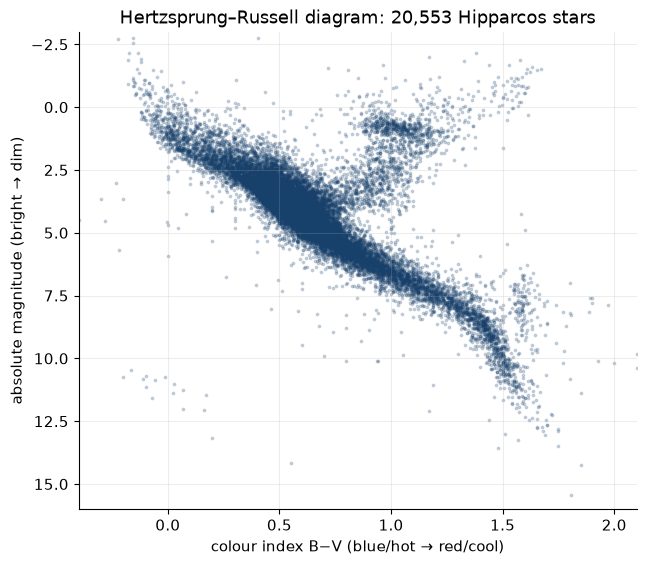

In [5]:
hip = pd.read_csv(DATA / "hipparcos.csv").rename(columns={"B-V": "b_v"})
hip["abs_mag"] = hip["Vmag"] + 5 * np.log10(hip["Plx"] / 100)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.scatter(hip["b_v"], hip["abs_mag"], s=3, alpha=0.2, color="#17406b")
ax.set_xlim(-0.4, 2.1)
ax.set_ylim(16, -3)  # reversed: bright stars at the top
ax.set_xlabel("colour index B−V (blue/hot → red/cool)")
ax.set_ylabel("absolute magnitude (bright → dim)")
ax.set_title(f"Hertzsprung–Russell diagram: {len(hip):,} Hipparcos stars")
plt.show()

In [6]:
assert len(hip) > 15000
assert (hip["Plx"] > 10).all(), "The extract is limited to parallax > 10 mas."
star = hip[hip["HIP"] == 2].iloc[0]
assert abs(star["abs_mag"] - (9.27 + 5 * np.log10(21.9 / 100))) < 0.01
assert ax.get_ylim()[0] > ax.get_ylim()[1], "Magnitude axis must run bright-to-dim."
print(f"✓ {len(hip):,} real Hipparcos stars; distance modulus and reversed axis verified")

✓ 20,553 real Hipparcos stars; distance modulus and reversed axis verified


**Example solution:** With the axis unflipped the main sequence appears to run
from faint-blue to bright-red — the opposite of the physical reading — because
magnitude is an inverted scale; conventions are part of the encoding and must
be stated. A 500-star subsample still shows the main sequence clearly: the
diagonal band is dense enough to survive heavy thinning, though the sparse
giant branch and white-dwarf corner fade first. Rare subpopulations, not the
main trend, set the sample-size requirement.

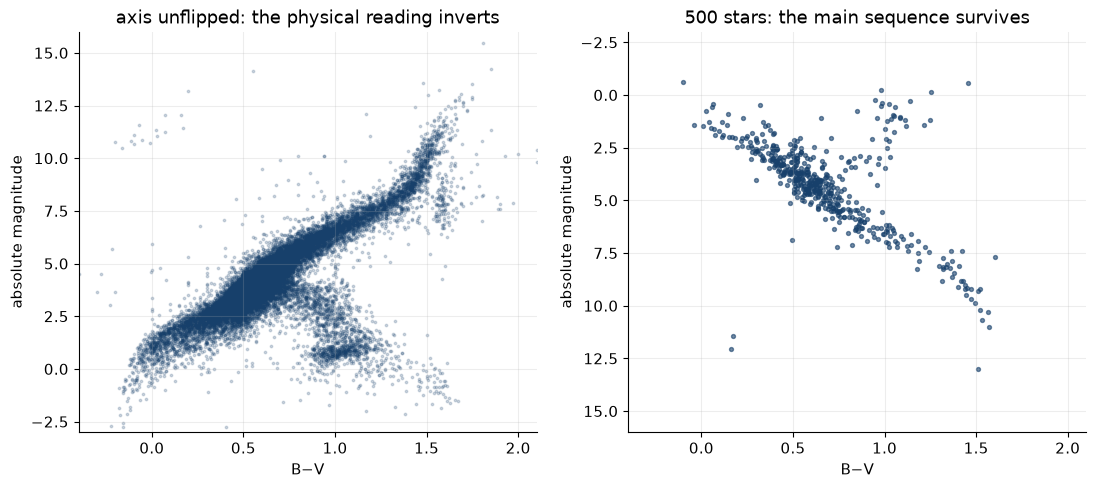

In [7]:
# Example intervention: unflipped axis, then a 500-star subsample.
sample = hip.sample(500, random_state=36104)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes[0].scatter(hip["b_v"], hip["abs_mag"], s=3, alpha=0.2, color="#17406b")
axes[0].set_ylim(-3, 16)  # NOT reversed
axes[0].set_title("axis unflipped: the physical reading inverts")
axes[1].scatter(sample["b_v"], sample["abs_mag"], s=8, alpha=0.6, color="#17406b")
axes[1].set_ylim(16, -3)
axes[1].set_title("500 stars: the main sequence survives")
for ax in axes:
    ax.set_xlim(-0.4, 2.1)
    ax.set_xlabel("B−V")
    ax.set_ylabel("absolute magnitude")
plt.show()

## 3 · The Mohs hardness scale: ranking

*Atlas #2 — Mohs hardness scale.*

Friedrich Mohs published his ten-mineral scratch scale in 1812 as a ranked
list, not a chart: each mineral scratches every mineral below it. Rank is an
ordinal reading — the order is real, the spacing is not. The absolute values
below are Tabor's measured Vickers indentation hardness numbers for the Mohs
minerals (Tabor 1954), so both columns are real.

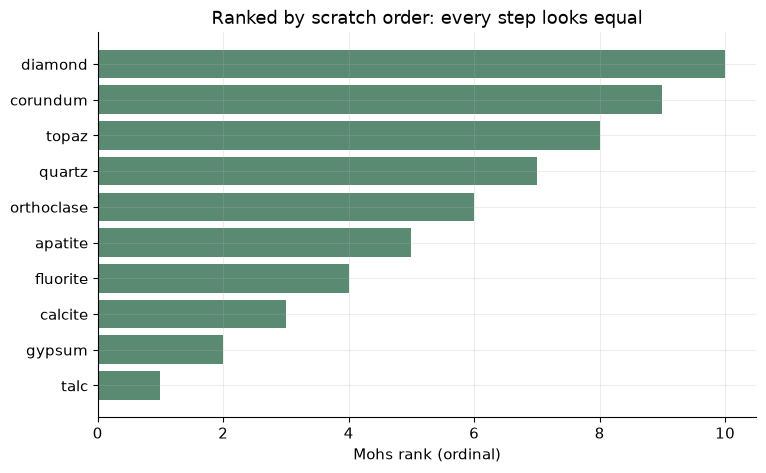

In [8]:
mohs = pd.DataFrame({
    "mineral": ["talc", "gypsum", "calcite", "fluorite", "apatite",
                "orthoclase", "quartz", "topaz", "corundum", "diamond"],
    "mohs_rank": np.arange(1, 11),
    "vickers": [2.4, 36, 109, 189, 536, 714, 1120, 1427, 2060, 10060],
})

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(mohs["mineral"], mohs["mohs_rank"], color="#5b8a72")
ax.set_xlim(left=0)
ax.set_xlabel("Mohs rank (ordinal)")
ax.set_title("Ranked by scratch order: every step looks equal")
plt.show()

In [9]:
assert mohs["mohs_rank"].tolist() == list(range(1, 11))
assert mohs["vickers"].is_monotonic_increasing
assert mohs["vickers"].iloc[-1] / mohs["vickers"].iloc[-2] > 4
print("✓ complete ordinal scale; Tabor's measured hardness monotone but with wildly unequal steps")

✓ complete ordinal scale; Tabor's measured hardness monotone but with wildly unequal steps


**Example solution:** The equal ordinal steps conceal that the true intervals
are wildly unequal: on a linear scale diamond (10,060) dwarfs corundum
(2,060) — one Mohs step hides a five-fold jump — while the first five minerals
become almost indistinguishable. The log scale makes the ratios readable
again. Alphabetical order destroys the ranking reading entirely; only value
lookup survives, which is why sort order must follow the analytical task.

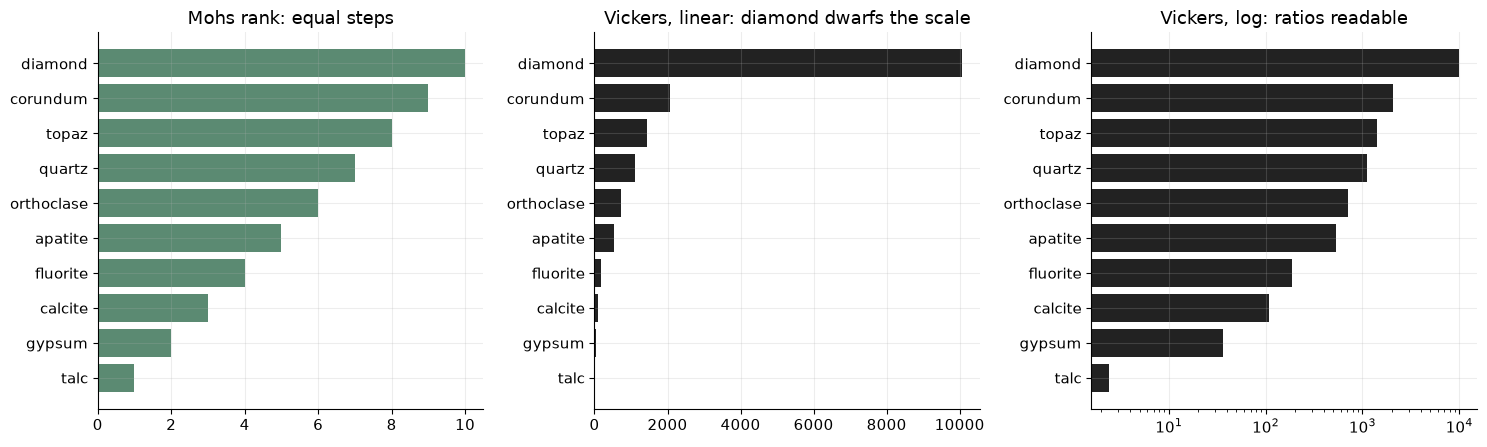

In [10]:
# Example intervention: ordinal rank vs measured hardness, linear and log.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
axes[0].barh(mohs["mineral"], mohs["mohs_rank"], color="#5b8a72")
axes[0].set_title("Mohs rank: equal steps")
axes[1].barh(mohs["mineral"], mohs["vickers"], color="#222222")
axes[1].set_title("Vickers, linear: diamond dwarfs the scale")
axes[2].barh(mohs["mineral"], mohs["vickers"], color="#222222")
axes[2].set_xscale("log")
axes[2].set_title("Vickers, log: ratios readable")
plt.tight_layout()
plt.show()

## 4 · The mirrored age–sex form: distribution

*Atlas #3 — Population pyramid.*

![Walker's 1874 age-and-sex distribution of deaths](../../../shared/assets/originals/walker-1874-age-sex-deaths.jpg)

Walker's 1874 plate showed the age and sex distribution **of deaths**.
`data/nchs_deaths_by_age_sex.csv` is the same variable measured today: US
all-cause deaths by age group and sex, 2020–2023, from the National Center
for Health Statistics (snapshot 13 August 2026). Deaths are not population:
mortality bumps in infancy, stays low through youth and rises steeply in old
age, so the silhouette is pinched, not a smooth pyramid.

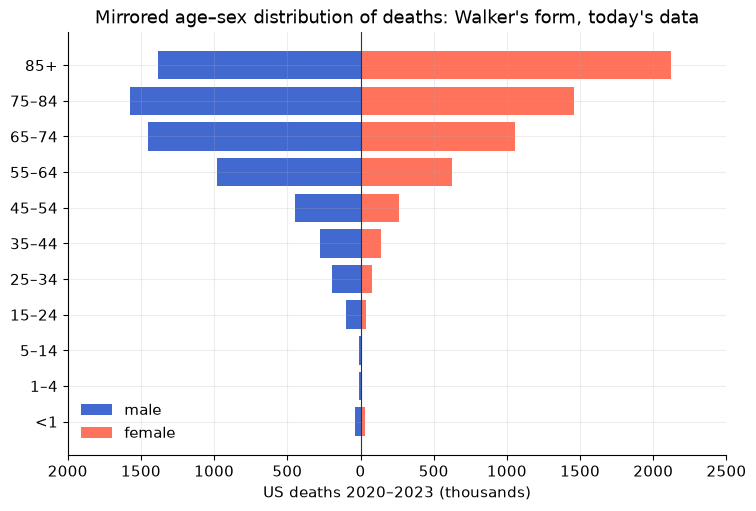

In [11]:
bands = ["Under 1 year", "1-4 years", "5-14 years", "15-24 years",
         "25-34 years", "35-44 years", "45-54 years", "55-64 years",
         "65-74 years", "75-84 years", "85 years and over"]
band_labels = ["<1", "1–4", "5–14", "15–24", "25–34", "35–44",
               "45–54", "55–64", "65–74", "75–84", "85+"]

deaths = pd.read_csv(DATA / "nchs_deaths_by_age_sex.csv")
pyramid = (deaths[deaths["age_group"].isin(bands)]
           .pivot(index="age_group", columns="sex", values="total_deaths")
           .loc[bands] / 1000)
y = np.arange(len(bands))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(y, -pyramid["Male"], color="#4269d0", label="male")
ax.barh(y, pyramid["Female"], color="#ff725c", label="female")
ax.set_yticks(y, band_labels)
ax.set_xlabel("US deaths 2020–2023 (thousands)")
ticks = ax.get_xticks()
ax.set_xticks(ticks, [f"{abs(int(tick))}" for tick in ticks])
ax.axvline(0, color="#333333", lw=0.8)
ax.set_title("Mirrored age–sex distribution of deaths: Walker's form, today's data")
ax.legend(frameon=False)
plt.show()

In [12]:
all_ages = (deaths[deaths["age_group"] == "All Ages"]
            .set_index("sex")["total_deaths"] / 1000)
assert set(pyramid.columns) == {"Male", "Female"}
assert len(pyramid) == 11
for sex in ["Male", "Female"]:
    assert abs(pyramid[sex].sum() - all_ages[sex]) / all_ages[sex] < 0.02, \
        "Non-overlapping bands should reproduce the All Ages total."
assert pyramid.loc["Under 1 year"].sum() > pyramid.loc["1-4 years"].sum(), \
    "Infant mortality exceeds early-childhood mortality."
print("✓ real NCHS counts; bands reconcile with totals and show the infant bump")

✓ real NCHS counts; bands reconcile with totals and show the infant bump


**Example solution:** Ordering the bands by count destroys the ordinal age
sequence — 'Under 1' lands between the young-adult bands because of the infant
bump — so the silhouette no longer represents a distribution through age:
every bar is correct and the shape means nothing. The mirrored form makes the
overall shapes and the sex difference at each age visible (male deaths exceed
female up to old age; the pattern reverses at 85+ because more women survive
to that band); grouped bars make exact within-age comparisons easier but
weaken the continuous silhouette.

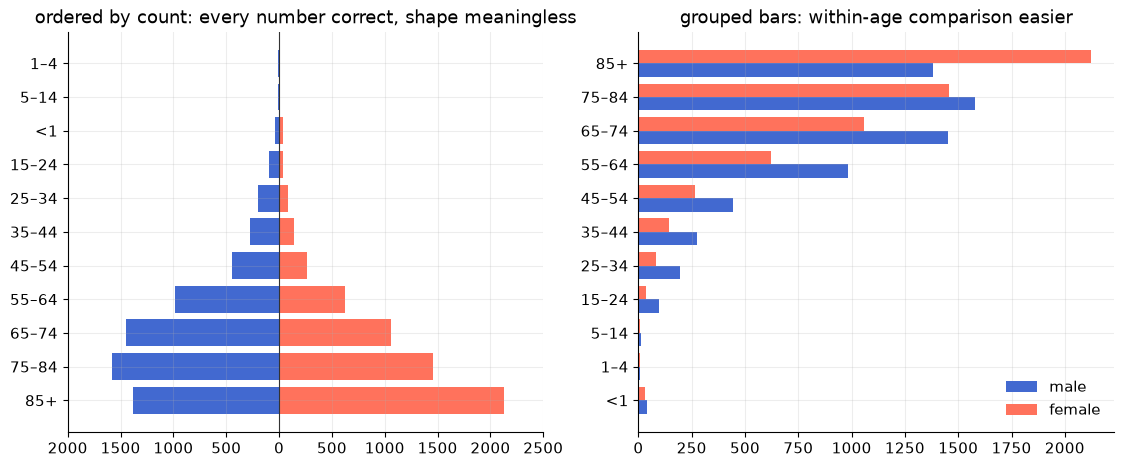

In [13]:
# Example intervention: count-ordered bands break the silhouette; grouped bars ease comparison.
by_count = pyramid.sort_values("Female", ascending=False)
labels_by_count = [band_labels[bands.index(b)] for b in by_count.index]
y_broken = np.arange(len(by_count))
width = 0.4
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
axes[0].barh(y_broken, -by_count["Male"], color="#4269d0")
axes[0].barh(y_broken, by_count["Female"], color="#ff725c")
axes[0].set_yticks(y_broken, labels_by_count)
axes[0].axvline(0, color="#333333", lw=0.8)
ticks = axes[0].get_xticks()
axes[0].set_xticks(ticks, [f"{abs(int(t))}" for t in ticks])
axes[0].set_title("ordered by count: every number correct, shape meaningless")
axes[1].barh(y - width / 2, pyramid["Male"], height=width, color="#4269d0", label="male")
axes[1].barh(y + width / 2, pyramid["Female"], height=width, color="#ff725c", label="female")
axes[1].set_yticks(y, band_labels)
axes[1].set_title("grouped bars: within-age comparison easier")
axes[1].legend(frameon=False)
plt.show()

## 5 · The Keeling curve: change over time

![NOAA/Scripps full Mauna Loa record](../../../shared/assets/originals/keeling-curve-noaa-2026-08-05.png)

This section uses NOAA's downloadable monthly data. `average` retains the seasonal
saw-tooth; `deseasonalized` exposes the underlying trend. Missing early metadata are
negative sentinel values in other columns, so we select only the fields we need.

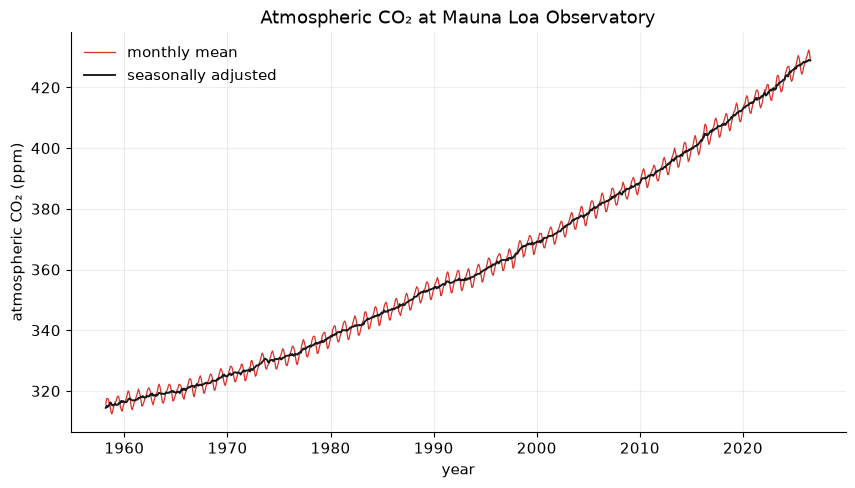

In [14]:
co2 = pd.read_csv(DATA / "co2_mm_mlo.csv", comment="#")
co2["date"] = pd.to_datetime(dict(year=co2["year"], month=co2["month"], day=15))

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(co2["date"], co2["average"], color="#d73027", lw=0.9,
        label="monthly mean")
ax.plot(co2["date"], co2["deseasonalized"], color="#171717", lw=1.35,
        label="seasonally adjusted")
ax.set_xlabel("year")
ax.set_ylabel("atmospheric CO₂ (ppm)")
ax.set_title("Atmospheric CO₂ at Mauna Loa Observatory")
ax.legend(frameon=False)
plt.show()

In [15]:
assert co2["date"].is_monotonic_increasing
assert co2["average"].notna().all()
assert co2.loc[co2["year"] == 1958, "average"].mean() < 320
assert co2.loc[co2["year"] == 2025, "average"].mean() > 420
print(f"✓ {len(co2):,} monthly observations; date order and endpoints verified")

✓ 821 monthly observations; date order and endpoints verified


**Example solution:** The short window enlarges the seasonal oscillation relative to
the visible vertical range and hides most of the long-run accumulation. The full
record makes the persistent rise dominant. Both use the same observations; the time
window changes the comparison the reader can make.

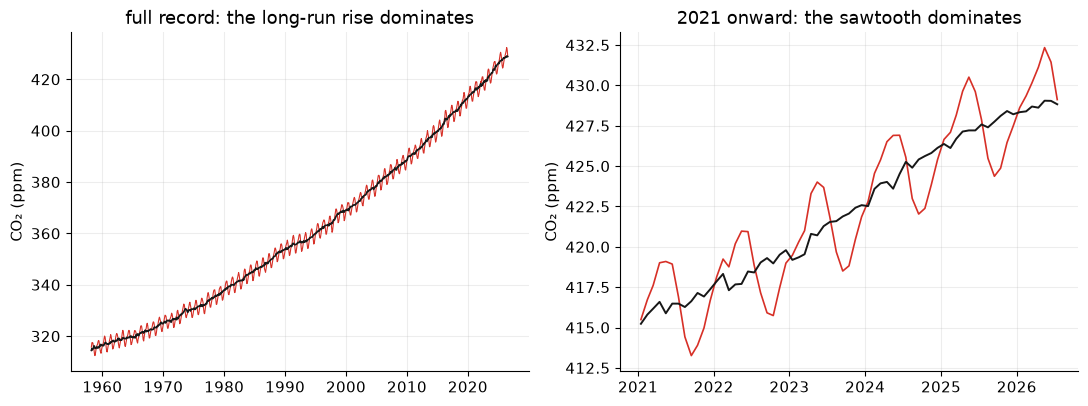

In [16]:
# Example intervention: the same record, full and cropped to 2021 onward.
recent = co2[co2["year"] >= 2021]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(co2["date"], co2["average"], color="#d73027", lw=0.8)
axes[0].plot(co2["date"], co2["deseasonalized"], color="#171717", lw=1.2)
axes[0].set_title("full record: the long-run rise dominates")
axes[1].plot(recent["date"], recent["average"], color="#d73027", lw=1.2)
axes[1].plot(recent["date"], recent["deseasonalized"], color="#171717", lw=1.4)
axes[1].set_title("2021 onward: the sawtooth dominates")
for ax in axes:
    ax.set_ylabel("CO\u2082 (ppm)")
plt.show()

## 6 · The trophic energy pyramid: magnitude

Ecology stacks the trophic levels with roughly ten per cent of each level's
energy reaching the next (after Elton 1927 and Lindeman 1942). The values
below are representative teaching units, not measurements of one ecosystem.
The visual task is magnitude: comparing absolute amounts across ordered
levels that span three orders of magnitude.

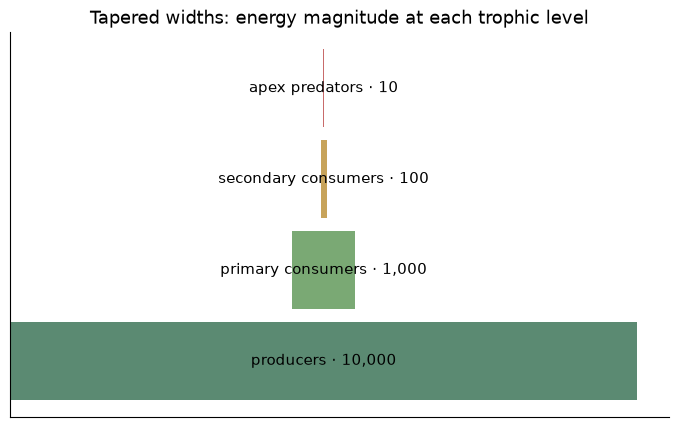

In [17]:
trophic = pd.DataFrame({
    "level": ["producers", "primary consumers", "secondary consumers", "apex predators"],
    "energy_units": [10000, 1000, 100, 10],
})
y = np.arange(len(trophic))  # producers at the bottom

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(y, trophic["energy_units"], left=-trophic["energy_units"] / 2,
        color=["#5b8a72", "#7aa974", "#c7a35a", "#c86b6b"], height=0.85)
for yi, level, value in zip(y, trophic["level"], trophic["energy_units"]):
    ax.text(0, yi, f"{level} · {value:,}", ha="center", va="center", fontsize=11)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Tapered widths: energy magnitude at each trophic level")
plt.show()

In [18]:
ratios = trophic["energy_units"].iloc[1:].to_numpy() / trophic["energy_units"].iloc[:-1].to_numpy()
assert np.allclose(ratios, 0.1), "Each level should hold ~10% of the level below."
assert (trophic["energy_units"] > 0).all()
assert trophic["energy_units"].is_monotonic_decreasing
print("✓ ordered levels with a ~10% transfer at every step verified")

✓ ordered levels with a ~10% transfer at every step verified


**Example solution:** On a common linear scale the apex bar is invisible next
to the producers : magnitude comparison fails across three orders of
magnitude : while the log scale renders every ~10× step as an equal visual
interval, making the transfer ratio the readable quantity. The pyramid is not
part-to-whole: the tiers are not shares of any fixed total, because roughly
90% of each level's energy is lost as heat at the transfer rather than passed
upward. A form that resembles composition invites a documented misreading.

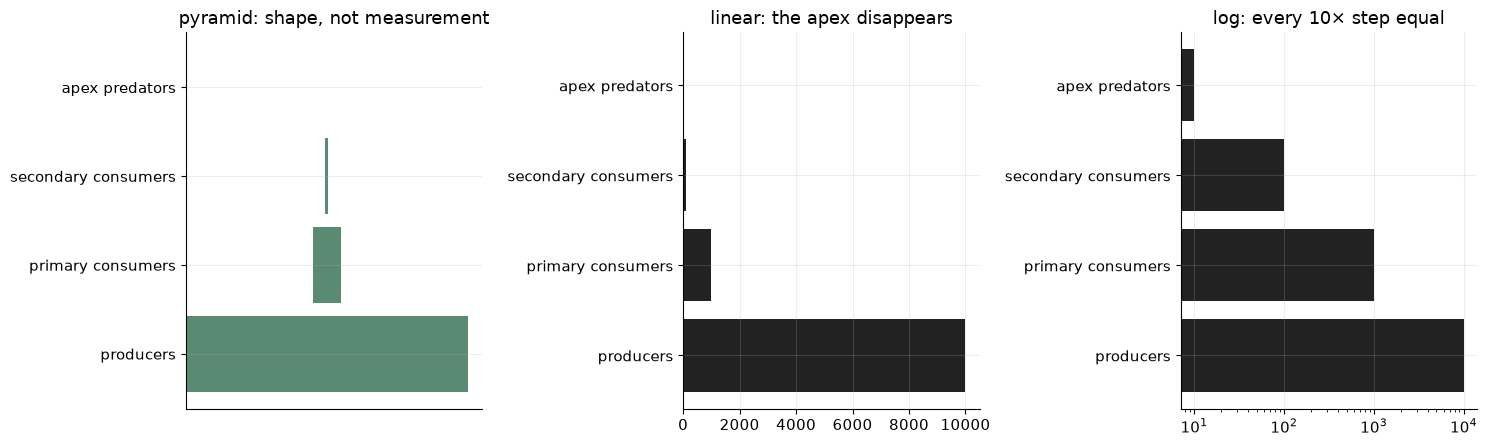

In [19]:
# Example intervention: pyramid vs common-scale bars vs log scale.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
axes[0].barh(y, trophic["energy_units"], left=-trophic["energy_units"] / 2,
             color="#5b8a72", height=0.85)
axes[0].set_xticks([])
axes[0].set_title("pyramid: shape, not measurement")
axes[1].barh(y, trophic["energy_units"], color="#222222")
axes[1].set_title("linear: the apex disappears")
axes[2].barh(y, trophic["energy_units"], color="#222222")
axes[2].set_xscale("log")
axes[2].set_title("log: every 10× step equal")
for ax in axes:
    ax.set_yticks(y, trophic["level"])
plt.tight_layout()
plt.show()

## 7 · Document-topic mixtures: part-to-whole

A topic model represents each document as a mixture of topics. Every row below
is one complete document and its topic proportions sum to 100%. The values are
illustrative model output. The part-to-whole task is direct: compare composition
within documents and compare those compositions across documents.

In [ ]:
topic_mix = pd.DataFrame({
    "document": ["d1", "d2", "d3", "d4", "d5", "d6"],
    "climate":  [0.62, 0.10, 0.08, 0.18, 0.45, 0.12],
    "finance":  [0.12, 0.68, 0.10, 0.22, 0.30, 0.18],
    "biology":  [0.18, 0.08, 0.72, 0.10, 0.15, 0.25],
    "politics": [0.08, 0.14, 0.10, 0.50, 0.10, 0.45],
})
topics = ["climate", "finance", "biology", "politics"]
topic_colours = ["#4269d0", "#efb118", "#ff725c", "#6cc5b0"]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(topic_mix))
for topic, colour in zip(topics, topic_colours):
    ax.bar(topic_mix["document"], topic_mix[topic], bottom=bottom,
           label=topic, color=colour)
    bottom += topic_mix[topic].to_numpy()
ax.set_ylim(0, 1)
ax.set_ylabel("topic proportion")
ax.set_title("Each document is a complete mixture of topics")
ax.legend(frameon=False, ncol=4)
plt.show()

In [ ]:
assert np.allclose(topic_mix[topics].sum(axis=1), 1)
assert topic_mix[topics].ge(0).all().all()
assert topic_mix[topics].le(1).all().all()
assert np.allclose(bottom, 1)
print("✓ every document is a complete non-negative composition")

**Example solution:** The pie chart makes the composition of `d1` visible as one
whole, but comparing documents would require several pies and repeated angle
judgements. The 100% stacked bars keep every document on the same scale. Sorting
by climate share makes that topic easy to rank but removes the original document
order.

In [ ]:
# Example intervention: one pie and stacked bars sorted by climate share.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
axes[0].pie(topic_mix.loc[0, topics], labels=topics, colors=topic_colours,
            autopct="%1.0f%%", startangle=90)
axes[0].set_title("d1: one composition")

ordered = topic_mix.sort_values("climate").reset_index(drop=True)
left = np.zeros(len(ordered))
for topic, colour in zip(topics, topic_colours):
    axes[1].barh(ordered["document"], ordered[topic], left=left,
                 color=colour, label=topic)
    left += ordered[topic].to_numpy()
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("topic proportion")
axes[1].set_title("documents ordered by climate share")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 8 · Dupin's choropleth: spatial

*Atlas #34 — Choropleth and cartogram.*

![Charles Dupin's 1826 choropleth](../../../shared/assets/originals/dupin-choropleth-1826.jpg)

Dupin shaded French departments by an education measure — the first modern
choropleth. This reconstruction applies his logic to real Australian data on
an abstract state tile map: ABS state and territory populations for the year
to December 2025 (released 18 June 2026). The crucial operation is Dupin's:
map a comparable **rate**, not a raw count.

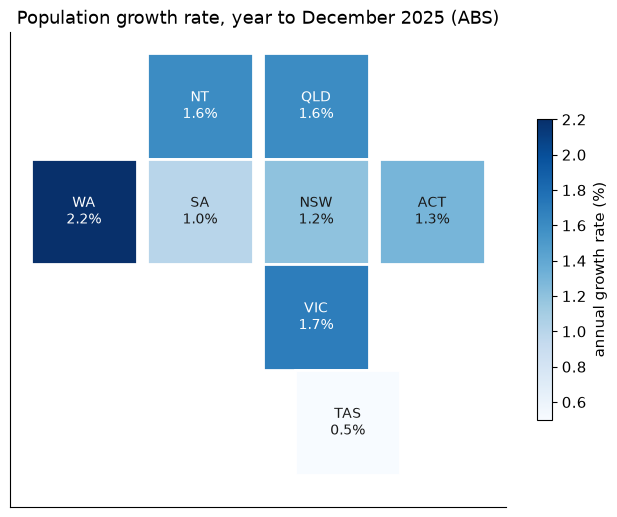

In [23]:
states = pd.DataFrame({
    "state": ["WA", "NT", "SA", "QLD", "NSW", "VIC", "TAS", "ACT"],
    "x":     [0.0,  1.1,  1.1,  2.2,   2.2,   2.2,   2.5,   3.3],
    "y":     [1.0,  2.0,  1.0,  2.0,   1.0,   0.0,  -1.0,   1.0],
    "population_thousands":    [3076.5, 267.5, 1910.6, 5712.1, 8641.1, 7121.9, 579.1, 487.2],
    "annual_change_thousands": [65.5,   4.2,   19.7,   92.2,   104.6,  117.3,  2.9,   6.0],
    "growth_rate_pct":         [2.2,    1.6,   1.0,    1.6,    1.2,    1.7,    0.5,   1.3],
})

norm_rate = Normalize(states["growth_rate_pct"].min(), states["growth_rate_pct"].max())
cmap_map = plt.get_cmap("Blues")
fig, ax = plt.subplots(figsize=(8, 6.5))
for row in states.itertuples(index=False):
    ax.add_patch(plt.Rectangle((row.x, row.y), 1, 1,
                 facecolor=cmap_map(norm_rate(row.growth_rate_pct)),
                 edgecolor="white", linewidth=2))
    ax.text(row.x + 0.5, row.y + 0.5, f"{row.state}\n{row.growth_rate_pct}%",
            ha="center", va="center", fontsize=10,
            color="white" if row.growth_rate_pct > 1.5 else "#1a1a1a")
ax.set(xlim=(-0.2, 4.5), ylim=(-1.3, 3.2), aspect="equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Population growth rate, year to December 2025 (ABS)")
sm = plt.cm.ScalarMappable(norm=norm_rate, cmap=cmap_map)
fig.colorbar(sm, ax=ax, shrink=0.6, label="annual growth rate (%)")
plt.show()

In [24]:
assert len(states) == 8 and states["state"].is_unique
assert states.loc[states["growth_rate_pct"].idxmax(), "state"] == "WA"
assert states.loc[states["growth_rate_pct"].idxmin(), "state"] == "TAS"
national_change = states["annual_change_thousands"].sum()
assert 380 < national_change < 440, "State changes should sum to national growth (~412k)."
print(f"✓ real ABS rates; WA fastest, TAS slowest; national change {national_change:.1f}k verified")

✓ real ABS rates; WA fastest, TAS slowest; national change 412.4k verified


**Example solution:** Shaded by raw change, Victoria and New South Wales
dominate simply because they are large — the map redraws population size, not
growth — while Western Australia, the fastest-growing state, fades to
mid-tone. Rates make unequal denominators comparable, which is exactly
Dupin's move. With three classes, WA keeps its lead but the 1.6–1.7 middle
(VIC, QLD, NT) collapses into one tone and the SA/ACT/NSW ordering vanishes
at the bin boundaries.

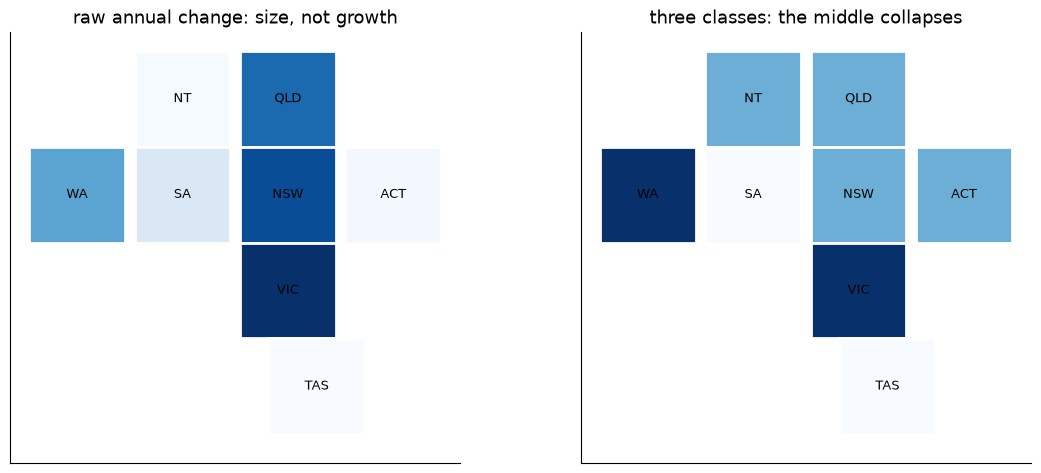

In [25]:
# Example intervention: raw change vs rate, then three classes.
from matplotlib.colors import BoundaryNorm

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
norm_count = Normalize(states["annual_change_thousands"].min(),
                       states["annual_change_thousands"].max())
for row in states.itertuples(index=False):
    axes[0].add_patch(plt.Rectangle((row.x, row.y), 1, 1,
                      facecolor=cmap_map(norm_count(row.annual_change_thousands)),
                      edgecolor="white", linewidth=2))
    axes[0].text(row.x + 0.5, row.y + 0.5, row.state, ha="center", va="center", fontsize=9)
axes[0].set_title("raw annual change: size, not growth")
bounds = np.linspace(states["growth_rate_pct"].min(), states["growth_rate_pct"].max(), 4)
norm_classes = BoundaryNorm(bounds, cmap_map.N)
for row in states.itertuples(index=False):
    axes[1].add_patch(plt.Rectangle((row.x, row.y), 1, 1,
                      facecolor=cmap_map(norm_classes(row.growth_rate_pct)),
                      edgecolor="white", linewidth=2))
    axes[1].text(row.x + 0.5, row.y + 0.5, row.state, ha="center", va="center", fontsize=9)
axes[1].set_title("three classes: the middle collapses")
for ax in axes:
    ax.set(xlim=(-0.2, 4.5), ylim=(-1.3, 3.2), aspect="equal")
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## 9 · Minard's march: spatial + flow

*Atlas #62 — Minard's march.*

![Minard's 1869 flow map](../../../shared/assets/originals/minard-1869.png)

The original combines geography, direction, army strength and the retreat
temperature. `data/minard_troops.csv` and `data/minard_temp.csv` are the
standard digitisation of Minard's printed values (via the HistData
collection): 51 route points with survivor counts for three army groups, and
the temperature record of the retreat.

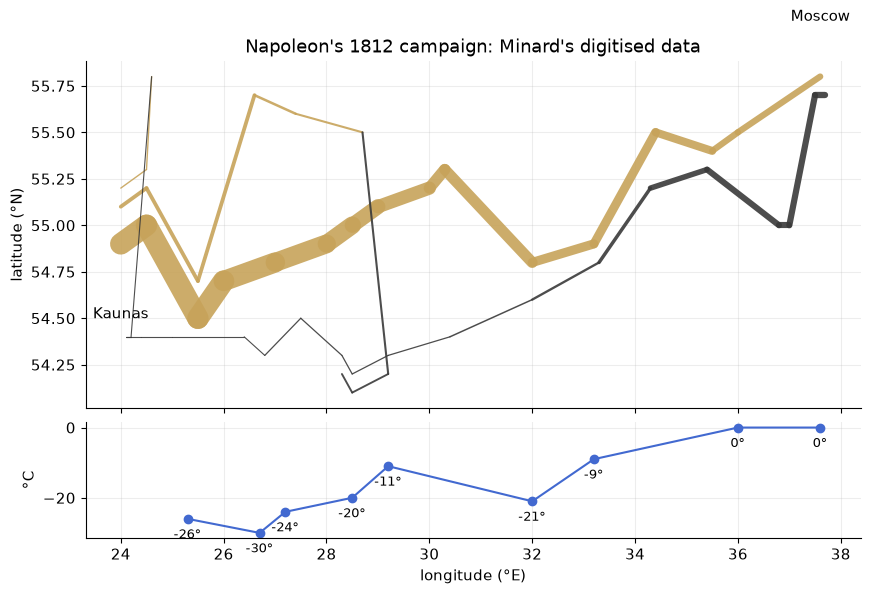

In [26]:
troops = pd.read_csv(DATA / "minard_troops.csv")
temps = pd.read_csv(DATA / "minard_temp.csv")
colours = {"A": "#c7a35a", "R": "#3a3a3a"}

fig, (ax_map, ax_t) = plt.subplots(
    2, 1, figsize=(10, 6.2), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06},
)
for (group, direction), g in troops.groupby(["group", "direction"]):
    g = g.reset_index(drop=True)
    for i in range(len(g) - 1):
        pair = g.iloc[i:i + 2]
        ax_map.plot(pair["long"], pair["lat"], color=colours[direction],
                    lw=max(0.8, pair.iloc[0]["survivors"] / 22000),
                    solid_capstyle="round", alpha=0.9)
ax_map.text(24.0, 54.5, "Kaunas", ha="center")
ax_map.text(37.6, 56.1, "Moscow", ha="center")
ax_map.set_ylabel("latitude (°N)")
ax_map.set_title("Napoleon's 1812 campaign: Minard's digitised data")

ax_t.plot(temps["long"], temps["temp"], "o-", color="#4269d0", lw=1.5)
for row in temps.itertuples(index=False):
    ax_t.annotate(f"{row.temp}°", (row.long, row.temp), xytext=(0, -14),
                  textcoords="offset points", ha="center", fontsize=9)
ax_t.set_xlabel("longitude (°E)")
ax_t.set_ylabel("°C")
plt.show()

In [27]:
assert troops["survivors"].max() == 340000, "The march begins with 340,000 men."
assert troops["survivors"].min() < 10000, "The retreat ends in the thousands."
assert set(troops["direction"]) == {"A", "R"}
assert troops["group"].nunique() == 3, "Minard drew three army groups."
assert temps["temp"].min() <= -24
print(f"✓ {len(troops)} digitised route points, three groups, retreat temperatures verified")

✓ 51 digitised route points, three groups, retreat temperatures verified


**Example solution:** Equal width removes the survivor count — a quantitative
ratio field carried by line width — and the map's story of attrition
disappears; what remains is only a route. One colour removes direction, a
nominal field carried by hue: advance and retreat collapse into a single
tangle and the reader can no longer tell that the thin black line is the same
army coming back. Each channel carries exactly one field, which is why
removing a channel deletes a variable.

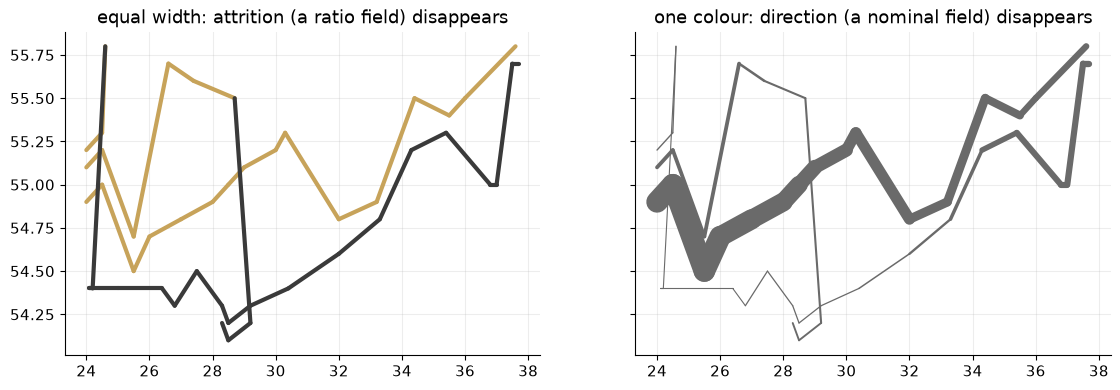

In [28]:
# Example intervention: equal width removes attrition; one colour removes direction.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), sharey=True)
for (group, direction), g in troops.groupby(["group", "direction"]):
    g = g.reset_index(drop=True)
    for i in range(len(g) - 1):
        pair = g.iloc[i:i + 2]
        axes[0].plot(pair["long"], pair["lat"], color=colours[direction],
                     lw=3, solid_capstyle="round")
        axes[1].plot(pair["long"], pair["lat"], color="#6a6a6a",
                     lw=max(0.8, pair.iloc[0]["survivors"] / 22000),
                     solid_capstyle="round")
axes[0].set_title("equal width: attrition (a ratio field) disappears")
axes[1].set_title("one colour: direction (a nominal field) disappears")
plt.show()

## Synthesis: from data type to visual vocabulary: example

| Reconstruction | Field types / roles | Visual Vocabulary task | Channels doing the work | What the original does that your code does not |
|---|---|---|---|---|
| Yield-curve spread | temporal + a signed difference with a meaningful zero | deviation | position, drawn zero reference, signed fill hue | FRED adds recession shading and institutional source context |
| HR diagram | ordered colour index + quantitative magnitude (reversed) | correlation | position on two scales | Russell drew it from 1913 parallaxes; ours are Hipparcos measurements |
| Mohs | ordinal rank + ratio hardness | ranking | position/length in rank order | an operational scratch-test definition, not a plotted value |
| Age–sex plate | ordinal age + ratio counts + nominal sex | distribution | mirrored length on a common scale | a historical plate designed for comparison with related demographic views |
| Keeling | temporal + ratio concentration | change over time | position along a common time axis | a maintained observatory record with provenance marks |
| Trophic pyramid | ordinal level + ratio energy | magnitude | width/length | measured energy budgets for a specific ecosystem |
| Topic mixtures | document identifier + topic proportions summing to one | part-to-whole | stacked length completing a common 100% scale | a fitted model would derive these shares from a real corpus |
| Choropleth | regional geometry + ratio rate | spatial | lightness on geography | Dupin used real departments on an engraved base map; ours is an abstract tile grid |
| Minard | spatial path + ratio strength + nominal direction + interval temperature | flow | position, width, hue, linked panel | geographic fidelity and six variables held in one frame |

### AI disclosure: example

- **Tool contributed:** drafting of reconstruction code and check cells.
- **How I checked it:** ran every cell; verified counts, sums, axis directions and
  totals against the stated properties in each verification cell.
- **What I wrote or decided:** the design interventions, the selected forms and
  every interpretation written in prose.
- **What requires independent verification:** assert what the historical
  originals contain, or claim simulated values as measurements.

## Sources and reuse notes

- Federal Reserve Bank of St. Louis, 10-Year Treasury Constant Maturity
  Minus 2-Year Treasury Constant Maturity [T10Y2Y], retrieved from FRED,
  12 August 2026. Reproduced with attribution.
- ESA, The Hipparcos and Tycho Catalogues (1997), catalogue I/239 via VizieR;
  extract limited to parallax > 10 mas with parallax error < 15%.
- D. Tabor, "Mohs's Hardness Scale — A Physical Interpretation," *Proceedings
  of the Physical Society B* 67 (1954): measured Vickers hardness of the Mohs
  minerals.
- National Center for Health Statistics, Provisional COVID-19 Deaths by Sex
  and Age (includes all-cause deaths), data.cdc.gov dataset 9bhg-hcku,
  snapshot 13 August 2026; US totals 2020–2023. Public domain.
- F. A. Walker, *Statistical Atlas of the United States* (1874), plate showing
  distribution by age and sex of deaths. Library of Congress; public domain.
- X. Lan, NOAA Global Monitoring Laboratory, and R. Keeling, Scripps
  Institution of Oceanography, Mauna Loa monthly CO₂ record. Data snapshot
  created 5 August 2026.
- C. Elton, *Animal Ecology* (1927); R. Lindeman, "The Trophic-Dynamic Aspect
  of Ecology," *Ecology* 23 (1942). Energy tiers are representative decade
  units; Lindeman measured transfer efficiencies of roughly 5–20%.
- D. Blei, A. Ng and M. Jordan, "Latent Dirichlet Allocation" (2003).
  Topic proportions in this notebook are illustrative model output.
- Australian Bureau of Statistics, National, state and territory population,
  December 2025 (released 18 June 2026). CC BY 4.0.
- C. Dupin, *Carte figurative de l'instruction populaire de la France* (1826),
  Bibliothèque nationale de France; public domain.
- C. J. Minard, *Carte figurative des pertes successives en hommes de l'Armée
  Française dans la campagne de Russie 1812–1813* (1869); route and
  temperature digitisation via the HistData collection (Minard.troops,
  Minard.temp).
- Reserve Bank of Australia chart pack, Australian Government Budget Balance
  (slide original); source Australian Treasury; © RBA, reproduced with
  attribution.

# Part 2 · Apply the framework

Use the transport dataset to complete the class workflow:

```text
data types → field combinations → required comparison → task family → visual form
```

The values are synthetic teaching data. Missing values and numeric strings are
intentional and must not be cleaned silently.

## Audience and question

- **Audience:** transport operations manager
- **Question:** Which mode carries the most passengers overall in 2025?
- **Decision supported:** Where should capacity monitoring be prioritised?
- **Likely Visual Vocabulary family:** magnitude, with ranking through sorting

In [29]:
# Build the supplied wide table. Run without editing.
rng = np.random.default_rng(36104)
months = pd.date_range("2025-01-01", periods=12, freq="MS")
messy = pd.DataFrame({
    "Month": months.strftime("%b-%Y"),
    "Bus passengers": rng.integers(820, 1280, 12).astype(str),
    "Train passengers": rng.integers(1050, 1650, 12).astype(str),
    "Ferry passengers": rng.integers(180, 430, 12).astype(str),
    "Bus delay min": np.round(rng.normal(7.5, 1.6, 12), 1),
    "Train delay min": np.round(rng.normal(5.5, 1.2, 12), 1),
    "Ferry delay min": np.round(rng.normal(4.0, 1.0, 12), 1),
})
messy.loc[4, "Train passengers"] = ".."
messy.loc[8, "Bus passengers"] = "1,204"
messy.loc[10, "Ferry delay min"] = np.nan
messy

,Month,Bus passengers,Train passengers,Ferry passengers,Bus delay min,Train delay min,Ferry delay min
0,Jan-2025,1128,1528,321,7.3,5.4,4.7
1,Feb-2025,870,1347,215,7.1,6.5,4.8
2,Mar-2025,1250,1470,246,8.8,6.2,4.9
3,Apr-2025,1103,1476,223,7.9,4.1,4.5
4,May-2025,860,..,201,5.7,4.3,2.2
5,Jun-2025,1223,1352,278,6.0,5.0,4.7
6,Jul-2025,1084,1087,238,8.4,8.8,3.9
7,Aug-2025,1225,1581,264,9.0,6.9,4.7
8,Sep-2025,"1,204",1241,259,4.5,4.8,3.8
9,Oct-2025,1027,1588,395,5.9,3.4,3.5


## Data types and tidy structure

Before writing code, record the data type and semantic role of every source field.
Then predict the tidy result:

- expected row count;
- expected unique modes;
- missing values that should remain;
- target type of `month`, `mode`, `passengers` and `average_delay_minutes`.

The tidy dataset must contain one observation per month and transport mode with
exactly these columns:

```text
month · mode · passengers · average_delay_minutes
```

In [30]:
passenger_cols = [c for c in messy.columns if c.endswith(" passengers")]
delay_cols = [c for c in messy.columns if c.endswith(" delay min")]

passengers = messy.melt(
    id_vars="Month", value_vars=passenger_cols,
    var_name="source", value_name="passengers",
)
passengers["mode"] = passengers["source"].str.removesuffix(" passengers")
passengers["passengers"] = pd.to_numeric(
    passengers["passengers"].str.replace(",", "", regex=False).replace("..", np.nan),
    errors="coerce",
)

delays = messy.melt(
    id_vars="Month", value_vars=delay_cols,
    var_name="source", value_name="average_delay_minutes",
)
delays["mode"] = delays["source"].str.removesuffix(" delay min")

tidy = passengers[["Month", "mode", "passengers"]].merge(
    delays[["Month", "mode", "average_delay_minutes"]],
    on=["Month", "mode"], validate="one_to_one",
)
tidy["month"] = pd.to_datetime(tidy.pop("Month"), format="%b-%Y")
tidy = tidy[["month", "mode", "passengers", "average_delay_minutes"]]
tidy.head()

,month,mode,passengers,average_delay_minutes
0,2025-01-01,Bus,1128.0,7.3
1,2025-02-01,Bus,870.0,7.1
2,2025-03-01,Bus,1250.0,8.8
3,2025-04-01,Bus,1103.0,7.9
4,2025-05-01,Bus,860.0,5.7


In [31]:
# Verification: identifiers, rows, types, missing values and a spot check.
assert tidy.shape == (36, 4), "Expected 12 months × 3 modes."
assert list(tidy.columns) == ["month", "mode", "passengers", "average_delay_minutes"]
assert set(tidy["mode"]) == {"Bus", "Train", "Ferry"}
assert pd.api.types.is_datetime64_any_dtype(tidy["month"])
assert pd.api.types.is_numeric_dtype(tidy["passengers"])
assert pd.api.types.is_numeric_dtype(tidy["average_delay_minutes"])
assert tidy["passengers"].isna().sum() == 1
assert tidy["average_delay_minutes"].isna().sum() == 1
bus_sep = tidy.loc[
    (tidy["mode"] == "Bus") & (tidy["month"] == pd.Timestamp("2025-09-01")),
    "passengers",
].iloc[0]
assert bus_sep == 1204, "The thousands separator was not handled correctly."
print("✓ identifiers, rows, types, missing values and spot value verified")
tidy.head()

✓ identifiers, rows, types, missing values and spot value verified


,month,mode,passengers,average_delay_minutes
0,2025-01-01,Bus,1128.0,7.3
1,2025-02-01,Bus,870.0,7.1
2,2025-03-01,Bus,1250.0,8.8
3,2025-04-01,Bus,1103.0,7.9
4,2025-05-01,Bus,860.0,5.7


## Field combinations and task families

| Question | Fields and data types | Required comparison | Task family |
|---|---|---|---|
| Which mode carries the most passengers overall? | mode: nominal; passengers: ratio | absolute totals and ordered position | magnitude / ranking |
| How does use change through the year? | month: temporal; passengers: ratio | trend and turning points | change over time |
| Do months with more passengers also have longer delays? | passengers: ratio; delay: ratio | paired association | correlation |
| Which mode has the most variable delays? | mode: nominal; delay: ratio | spread and outliers by group | distribution |
| How is total patronage divided among modes? | mode: nominal; passengers: ratio parts of one total | share of total | part-to-whole |

## Create three candidate forms

Create three charts from `tidy`. They must answer different questions rather
than apply different styling to the same chart.

Every chart must include an informative title, units, documented missing-value
treatment and consistent mode colours. Avoid unsupported causal claims.

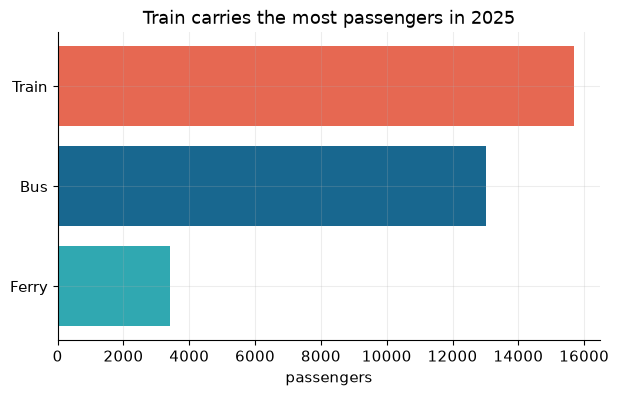

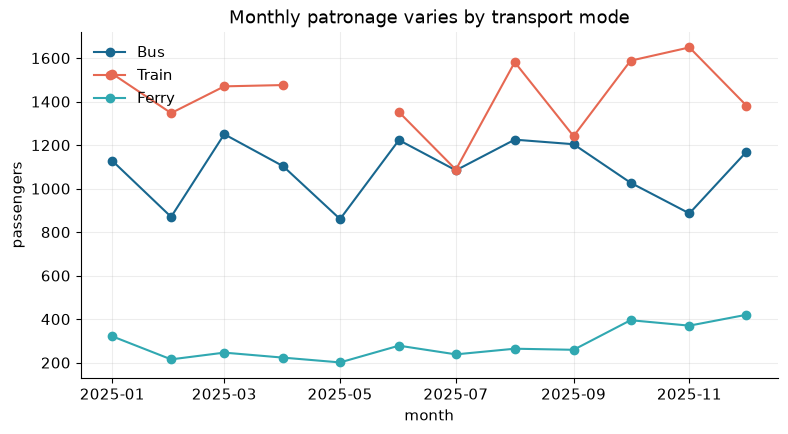

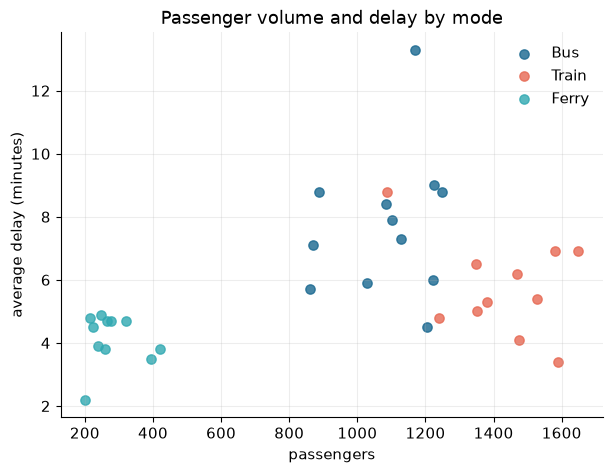

✓ ranked magnitude, temporal change and paired association views verified


In [32]:
mode_colours = {"Bus": "#18678f", "Train": "#e66852", "Ferry": "#30a8b1"}

totals = (tidy.groupby("mode", as_index=False)["passengers"]
          .sum(min_count=1).sort_values("passengers"))
fig, ax_rank = plt.subplots(figsize=(7, 4))
ax_rank.barh(totals["mode"], totals["passengers"],
             color=[mode_colours[m] for m in totals["mode"]])
ax_rank.set(xlabel="passengers", title="Train carries the most passengers in 2025")
ax_rank.set_xlim(left=0)
plt.show()

fig, ax_change = plt.subplots(figsize=(9, 4.5))
for mode, group in tidy.groupby("mode", sort=False):
    ax_change.plot(group["month"], group["passengers"], marker="o",
                   color=mode_colours[mode], label=mode)
ax_change.set(xlabel="month", ylabel="passengers",
              title="Monthly patronage varies by transport mode")
ax_change.legend(frameon=False)
plt.show()

fig, ax_corr = plt.subplots(figsize=(7, 5))
for mode, group in tidy.groupby("mode", sort=False):
    valid = group.dropna(subset=["passengers", "average_delay_minutes"])
    ax_corr.scatter(valid["passengers"], valid["average_delay_minutes"],
                    color=mode_colours[mode], label=mode, s=45, alpha=0.8)
ax_corr.set(xlabel="passengers", ylabel="average delay (minutes)",
            title="Passenger volume and delay by mode")
ax_corr.legend(frameon=False)
plt.show()

assert ax_rank.get_xlim()[0] == 0
assert len(ax_change.lines) == 3
assert len(ax_corr.collections) == 3
print("✓ ranked magnitude, temporal change and paired association views verified")

## Compare, select and reject: example

| Candidate | Question answered | Easy comparison | Information hidden | Audience risk |
|---|---|---|---|---|
| Ranked bars | Which mode carries most passengers? | totals and order | monthly variation and missing month | aggregation can conceal seasonal pressure |
| Lines | How does patronage change? | trend and turning points | precise overall rank | line continuity may overstate an isolated missing value |
| Scatterplot | Are passengers and delay associated? | paired association and outliers | temporal sequence | association may be read as causation |

- **Selected form:** ranked horizontal bars.
- **Why it fits:** the operations manager's stated question requires total magnitude and order.
- **Plausible alternative rejected:** line chart.
- **Reason:** it answers a change-over-time question rather than the stated total-capacity question.
- **Remaining limitation:** annual aggregation hides monthly peaks and the missing train observation.

## Explain and disclose: example

In the reshape, each `melt` changes twelve source rows into thirty-six
month-mode observations. `pd.to_numeric` changes passenger strings to a numeric
type while retaining `..` as missing. The `groupby` and sort determine the
comparison in the ranked-bar candidate. A new mode would require matching passenger
and delay column names; the chart loop and colour dictionary would also need a colour.

- **Tool used:** coding assistant.
- **Contribution:** proposed the two `melt` operations and first chart draft.
- **Accepted, modified or rejected:** retained the reshape; added explicit missing-value handling, `min_count=1`, labels and a zero baseline.
- **Verification:** ran the assertions, checked the September bus value manually and inspected all axes and missing values.
- **Remaining limitations:** synthetic data; no operational or causal claim can be generalised beyond the exercise.